<a href="https://colab.research.google.com/github/nikamaishwarya319-cmd/Student-attendence/blob/main/Student_Attendance_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Attendance Prediction Project

## **Step 1: Import Libraries**

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

## **Step 2: Data Collection**

In [78]:
df = pd.read_csv('Attendance_Prediction.csv')

### View Data

In [79]:
display(df.head())

,student_id,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,200.99,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,200.99,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,200.99,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,200.99,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,200.99,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


### Dataset Size

In [80]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (20000, 15)


### Column Names

In [81]:
print(f'Dataset columns: {df.columns.tolist()}')

Dataset columns: ['student_id', 'age', 'gender', 'course', 'year', 'parent_education', 'internet_access', 'hostel_resident', 'class_type', 'weather', 'study_hours', 'sleep_hours', 'travel_time_minutes', 'attendance', 'absence_reason']


## **Step 3: Data Cleaning**

### Information

In [82]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           20000 non-null  float64
 1   age                  20000 non-null  int64  
 2   gender               20000 non-null  object 
 3   course               20000 non-null  object 
 4   year                 20000 non-null  object 
 5   parent_education     20000 non-null  object 
 6   internet_access      20000 non-null  object 
 7   hostel_resident      20000 non-null  object 
 8   class_type           20000 non-null  object 
 9   weather              20000 non-null  object 
 10  study_hours          20000 non-null  float64
 11  sleep_hours          20000 non-null  float64
 12  travel_time_minutes  20000 non-null  int64  
 13  attendance           20000 non-null  int64  
 14  absence_reason       20000 non-null  object 
dtypes: float64(3), int64(3), object(9)
m

None

### Missing Values

In [106]:
df.isnull().sum()

,0
age,0
gender,0
course,0
year,0
parent_education,0
internet_access,0
hostel_resident,0
class_type,0
weather,0
study_hours,0


### Remove Missing Values

In [84]:
df = df.dropna()
print(f'Dataset shape after dropping missing values: {df.shape}')

Dataset shape after dropping missing values: (20000, 15)


### Duplicate Values

In [85]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


### Remove Duplicates

In [86]:
df = df.drop_duplicates()
print(f'Dataset shape after dropping duplicates: {df.shape}')

Dataset shape after dropping duplicates: (20000, 15)


### Drop `student_id`

In [87]:
if 'student_id' in df.columns:
    df = df.drop("student_id", axis=1)
    print("'student_id' column dropped.")
else:
    print("'student_id' column not found.")
display(df.head())

'student_id' column dropped.


,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,17,male,pharmacy,1st year,high school,no,yes,offline,sunny,3.63,7.24,31,1,none
1,23,other,diploma,2nd year,high school,yes,yes,offline,cloudy,4.39,7.98,50,0,no reason
2,22,male,b.sc,3rd year,no formal,yes,yes,online,rainy,5.43,6.53,62,1,none
3,20,other,pharmacy,2nd year,no formal,yes,yes,offline,cloudy,0.21,7.11,63,0,personal work
4,20,female,pharmacy,1st year,no formal,yes,yes,online,sunny,1.77,9.35,81,0,project work


## **Step 4: Data Preprocessing**

### Check Data Types

In [88]:
print(df.dtypes)

age                      int64
gender                  object
course                  object
year                    object
parent_education        object
internet_access         object
hostel_resident         object
class_type              object
weather                 object
study_hours            float64
sleep_hours            float64
travel_time_minutes      int64
attendance               int64
absence_reason          object
dtype: object


### Convert Categorical Columns to Numeric

In [89]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
display(df.head())

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason
0,17,1,8,0,1,0,1,0,4,3.63,7.24,31,1,2
1,23,2,6,1,1,1,1,0,0,4.39,7.98,50,0,1
2,22,1,1,2,2,1,1,1,3,5.43,6.53,62,1,2
3,20,2,8,1,2,1,1,0,0,0.21,7.11,63,0,3
4,20,0,8,0,2,1,1,1,4,1.77,9.35,81,0,4


## **Step 5: Feature Engineering**

### Create `study_sleep_ratio`

In [90]:
df["study_sleep_ratio"] = df["study_hours"] / df["sleep_hours"]
display(df.head())

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason,study_sleep_ratio
0,17,1,8,0,1,0,1,0,4,3.63,7.24,31,1,2,0.501381
1,23,2,6,1,1,1,1,0,0,4.39,7.98,50,0,1,0.550125
2,22,1,1,2,2,1,1,1,3,5.43,6.53,62,1,2,0.831547
3,20,2,8,1,2,1,1,0,0,0.21,7.11,63,0,3,0.029536
4,20,0,8,0,2,1,1,1,4,1.77,9.35,81,0,4,0.189305


### Create `travel_category`

In [91]:
df["travel_category"] = pd.cut(
    df["travel_time_minutes"],
    bins=[0,30,60,90],
    labels=False
)
# Encode the newly created categorical feature
df['travel_category'] = le.fit_transform(df['travel_category'])
display(df.head())

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason,study_sleep_ratio,travel_category
0,17,1,8,0,1,0,1,0,4,3.63,7.24,31,1,2,0.501381,1
1,23,2,6,1,1,1,1,0,0,4.39,7.98,50,0,1,0.550125,1
2,22,1,1,2,2,1,1,1,3,5.43,6.53,62,1,2,0.831547,2
3,20,2,8,1,2,1,1,0,0,0.21,7.11,63,0,3,0.029536,2
4,20,0,8,0,2,1,1,1,4,1.77,9.35,81,0,4,0.189305,2


## **Step 6: Feature Scaling**

In [92]:
scaler = StandardScaler()

num_cols = [
    "age",
    "study_hours",
    "sleep_hours",
    "travel_time_minutes",
    "study_sleep_ratio"
]

df[num_cols] = scaler.fit_transform(df[num_cols])
display(df.head())

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason,study_sleep_ratio,travel_category
0,-1.520442,1,8,0,1,0,1,0,4,0.370749,0.129961,-0.649976,1,2,0.149279,1
1,1.106067,2,6,1,1,1,1,0,0,0.810710,0.555454,0.122928,0,1,0.311293,1
2,0.668315,1,1,2,2,1,1,1,3,1.412761,-0.278283,0.611078,1,2,1.246671,2
3,-0.207188,2,8,1,2,1,1,0,0,-1.609074,0.055212,0.651757,0,3,-1.419022,2
4,-0.207188,0,8,0,2,1,1,1,4,-0.705997,1.343193,1.383982,0,4,-0.887988,2


## **Step 7: Exploratory Data Analysis (EDA)**

### Statistical Summary

In [107]:
df.describe()

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason,study_sleep_ratio,travel_category
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,2.000000e+04,2.000000e+04,2.000000e+04,20000.000000,20000.000000,2.000000e+04,20000.000000
mean,7.208456e-16,1.007350,4.004250,1.502950,2.009150,0.801450,0.60005,0.302700,2.003050,1.609379e-16,9.805490e-17,9.237056e-17,0.516350,2.478700,-4.050094e-17,1.036550
std,1.000025e+00,0.815616,2.579799,1.118729,1.413424,0.398918,0.48990,0.459438,1.420789,1.000025e+00,1.000025e+00,1.000025e+00,0.499745,1.488374,1.000025e+00,0.805696
min,-1.520442e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-1.701698e+00,-1.698512e+00,-1.707634e+00,0.000000,0.000000,-1.500440e+00,0.000000
25%,-1.082691e+00,0.000000,2.000000,0.000000,1.000000,1.000000,0.00000,0.000000,1.000000,-8.738767e-01,-8.705245e-01,-8.533715e-01,0.000000,2.000000,-8.209093e-01,0.000000
50%,-2.071878e-01,1.000000,4.000000,2.000000,2.000000,1.000000,1.00000,0.000000,2.000000,-5.533085e-03,-2.287316e-03,8.908737e-04,1.000000,2.000000,-9.781804e-02,1.000000
75%,6.683153e-01,2.000000,6.000000,3.000000,3.000000,1.000000,1.00000,1.000000,3.000000,8.628105e-01,8.774497e-01,8.551533e-01,1.000000,3.000000,6.263657e-01,2.000000
max,1.543818e+00,2.000000,8.000000,3.000000,4.000000,1.000000,1.00000,1.000000,4.000000,1.702209e+00,1.682438e+00,1.709416e+00,1.000000,6.000000,3.337465e+00,2.000000


### Mean

In [108]:
df.mean(numeric_only=True)

,0
age,7.208456e-16
gender,1.007350e+00
course,4.004250e+00
year,1.502950e+00
parent_education,2.009150e+00
internet_access,8.014500e-01
hostel_resident,6.000500e-01
class_type,3.027000e-01
weather,2.003050e+00
study_hours,1.609379e-16


### Median

In [109]:
df.median(numeric_only=True)

,0
age,-0.207188
gender,1.000000
course,4.000000
year,2.000000
parent_education,2.000000
internet_access,1.000000
hostel_resident,1.000000
class_type,0.000000
weather,2.000000
study_hours,-0.005533


### Mode

In [110]:
df.mode()

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason,study_sleep_ratio,travel_category
0,0.230564,2.0,7.0,2.0,4.0,1.0,1.0,0.0,0.0,-1.701698,1.682438,0.855153,1.0,2.0,0.144688,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.221266,NaN,NaN,NaN,NaN


### Correlation

In [111]:
df.corr(numeric_only=True)

,age,gender,course,year,parent_education,internet_access,hostel_resident,class_type,weather,study_hours,sleep_hours,travel_time_minutes,attendance,absence_reason,study_sleep_ratio,travel_category
age,1.000000,-0.001143,0.004868,0.016260,0.009669,-0.001675,-0.002773,0.002889,-0.002047,0.006626,0.000907,-0.002490,-0.000253,-0.004682,0.004814,-0.003232
gender,-0.001143,1.000000,0.011273,0.004497,-0.003311,-0.000125,-0.000527,-0.003936,0.003174,0.000716,-0.002990,-0.005955,0.006636,-0.001169,0.005315,-0.006877
course,0.004868,0.011273,1.000000,0.007697,-0.001080,0.002715,-0.000079,-0.000664,0.007963,0.007742,0.003505,0.000866,-0.003176,-0.003903,0.003580,-0.000965
year,0.016260,0.004497,0.007697,1.000000,0.007968,-0.007931,-0.001360,-0.006602,-0.004142,-0.008924,-0.005125,0.004850,0.006622,-0.001148,-0.007163,0.004956
parent_education,0.009669,-0.003311,-0.001080,0.007968,1.000000,-0.001478,0.001602,0.001356,-0.001981,-0.001637,-0.008316,0.008486,0.002938,0.003313,0.003583,0.008268
internet_access,-0.001675,-0.000125,0.002715,-0.007931,-0.001478,1.000000,0.002507,-0.013635,-0.016576,0.011571,0.000271,-0.002039,-0.005160,0.002435,0.009718,-0.000134
hostel_resident,-0.002773,-0.000527,-0.000079,-0.001360,0.001602,0.002507,1.000000,-0.010820,-0.011825,-0.003439,-0.010519,0.002254,-0.008520,-0.007535,0.002053,-0.000714
class_type,0.002889,-0.003936,-0.000664,-0.006602,0.001356,-0.013635,-0.010820,1.000000,-0.006317,-0.000461,0.015795,0.001570,0.109329,-0.036492,-0.009659,-0.000442
weather,-0.002047,0.003174,0.007963,-0.004142,-0.001981,-0.016576,-0.011825,-0.006317,1.000000,-0.006503,0.017958,-0.007295,-0.033415,0.007751,-0.017234,-0.002762
study_hours,0.006626,0.000716,0.007742,-0.008924,-0.001637,0.011571,-0.003439,-0.000461,-0.006503,1.000000,-0.008663,-0.003309,0.201739,-0.057840,0.881099,-0.001107


## **Step 8: Visualizations**

### Histogram

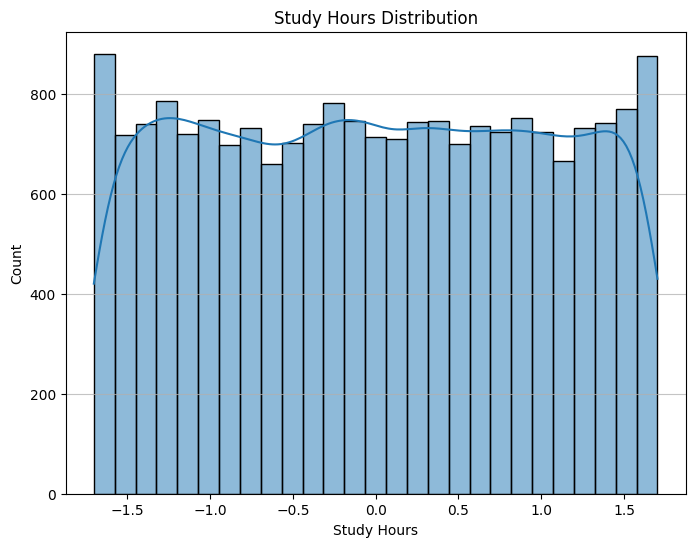

In [116]:
plt.figure(figsize=(8, 6))
sns.histplot(df["study_hours"], kde=True)
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.75)
plt.show()

### Bar Chart: Attendance Distribution

/tmp/ipykernel_1944/3200496053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="attendance", data=df, palette='viridis')


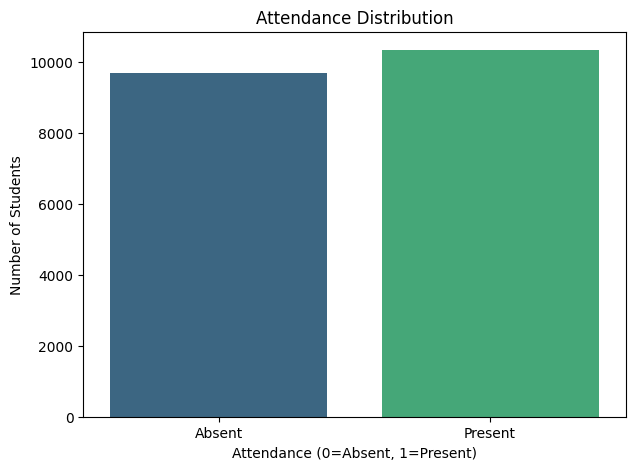

In [118]:
plt.figure(figsize=(7, 5))
sns.countplot(x="attendance", data=df, palette='viridis')
plt.title("Attendance Distribution")
plt.xlabel("Attendance (0=Absent, 1=Present)")
plt.ylabel("Number of Students")
plt.xticks([0, 1],['Absent', 'Present'])
plt.show()

### Scatter Plot: Study Hours vs. Attendance

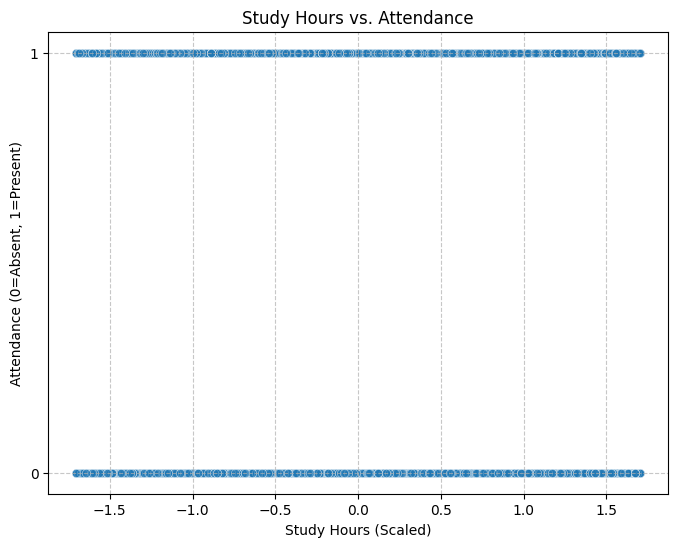

In [100]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="study_hours", y="attendance", data=df, alpha=0.6)
plt.title("Study Hours vs. Attendance")
plt.xlabel("Study Hours (Scaled)")
plt.ylabel("Attendance (0=Absent, 1=Present)")
plt.yticks([0, 1])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Box Plot: Study Hours

/tmp/ipykernel_1944/56796314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df["study_hours"], palette='pastel')


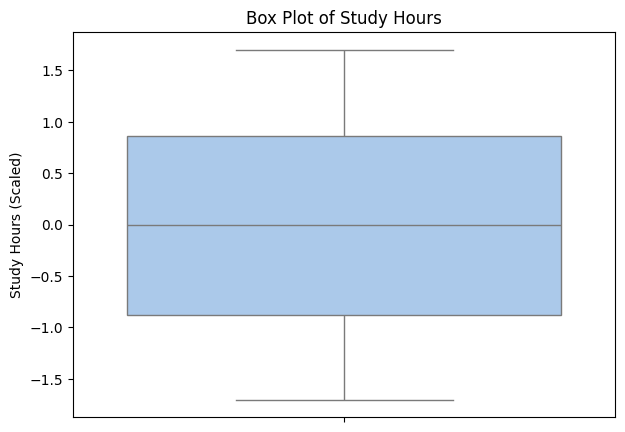

In [101]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=df["study_hours"], palette='pastel')
plt.title("Box Plot of Study Hours")
plt.ylabel("Study Hours (Scaled)")
plt.show()

### Pie Chart: Attendance Distribution

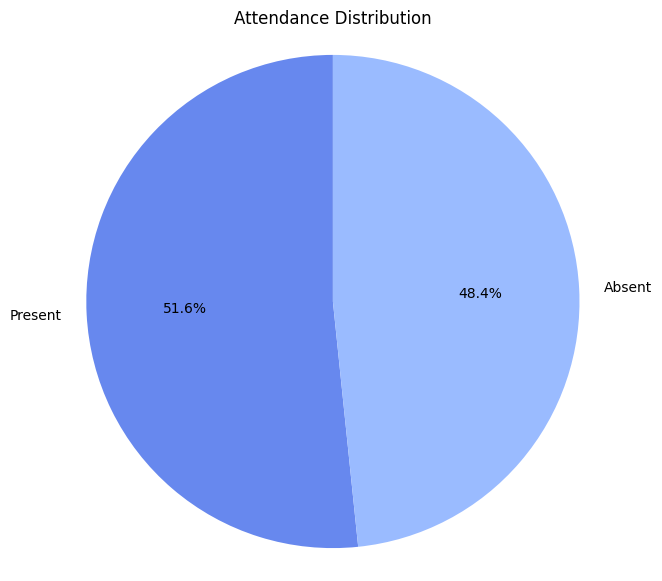

In [120]:
attendance_counts = df["attendance"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(attendance_counts, labels=['Present', 'Absent'], autopct='%1.1f%%',startangle=90, colors=sns.color_palette('coolwarm'))
plt.title("Attendance Distribution")
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Correlation Heatmap

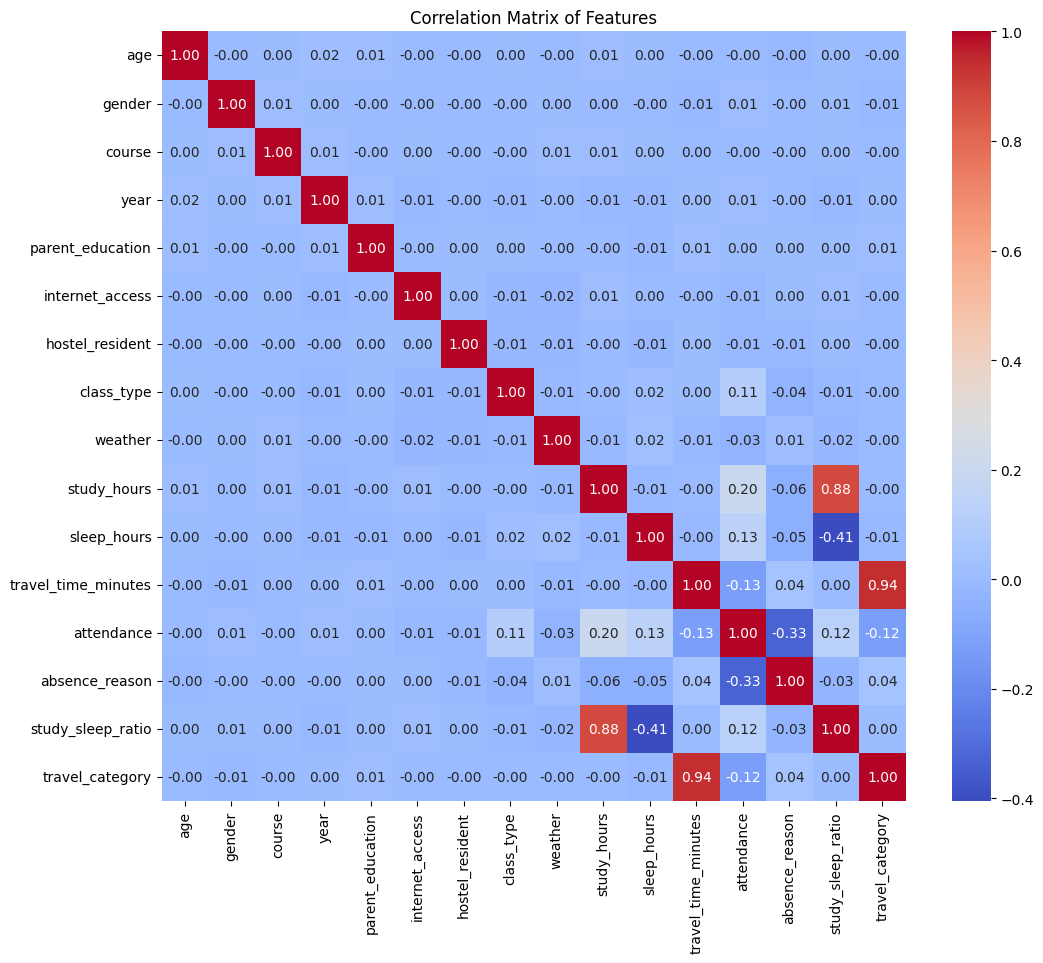

In [103]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

## **Step 9: Train-Test Split**

In [104]:
# Define features (X) and target (y)
X = df.drop('attendance', axis=1)
y = df['attendance']

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (16000, 15)
X_test shape: (4000, 15)
y_train shape: (16000,)
y_test shape: (4000,)


## **Step 10: Save Clean Dataset**

In [105]:
what is snsdf.to_csv("Cleaned_Attendance.csv", index=False)
print("Cleaned dataset saved to 'Cleaned_Attendance.csv'")

Cleaned dataset saved to 'Cleaned_Attendance.csv'
